# Surrogate vs. Real Pathways — validation

**Question:** how well does the XGBoost surrogate reproduce Uganda's 6 real named
pathways when we feed it each pathway's own policy-lever settings?

This is the check that motivates why the chatbot serves **real** pre-run data for the
6 named pathways (`pathways_lookup.py`) and uses the surrogate only for custom what-ifs.
It is re-runnable after any retrain.

### Method
1. **Real** emissions come from `pathways_lookup.get_pathway_emissions(pid)` — the 23
   official inventory categories, summed to a net total per year (from the corrected
   `uganda_pathways.csv`).
2. **Surrogate** emissions come from `predictor.predict(lever_overrides=...)`, where the
   levers are matched to each pathway from `tableau_levers_table.csv`.

### Vary ONLY the levers (L); hold the exogenous drivers (X) fixed
The 6 named pathways all share the **same reference future** (SISEPUEDE design 0 / future 0)
and differ only in **strategy (levers)**. So this sample **changes only L and holds X fixed**
at the central reference value (X = 0.5 for all 13 exogenous groups). That reference future is
*not* in the surrogate's training sample (it saw futures 1-12), so the surrogate **extrapolates**
for it — a structural source of gap (see BAU below), NOT an artifact of X drifting.

### Lever source (important caveats)
- `tableau_levers_table.csv` has strategy columns for **HBLE, NDC 2.5, NDC2 Unconditional,
  NDC2 Unconditional (Alt)** — 4 of the 6. **BAU** = no levers. **NDC 2.0** has no lever column,
  so it is skipped (info for 5 of 6).
- We map each surrogate lever group to a transformer by code
  (`TX:SEC:NAME_STRATEGY_NZ` -> `TFR:SEC:NAME`) and use the **final-year magnitude** as the
  lever intensity L in [0,1]. This is an **approximation** of the real run's levers.


## 1. Setup


In [1]:
import os, sys, json
# Run from the chatbot_deploy root so `backend.services` imports resolve.
_here = os.getcwd()
if os.path.basename(_here) == 'notebooks':
    os.chdir(os.path.dirname(_here))
print('cwd:', os.getcwd())

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

from backend.services import pathways_lookup as pl
from backend.services.predictor import get_sector_predictor
from backend.services import sector_crosswalk

pred = get_sector_predictor()
reg_full = json.load(open('backend/feature_registry.json'))
reg = reg_full['lever_features']
# Exogenous (X) groups — held FIXED at the central reference (0.5). We vary only L.
X_GROUPS = sorted(int(g) for g in reg_full['exogenous_features'])
FIXED_X = {g: 0.5 for g in X_GROUPS}
print('X groups held fixed at 0.5 (reference future):', X_GROUPS)

# tableau_levers_table.csv lives next to uganda_pathways.csv under the run's pathways/ dir.
import glob
LEVERS_CSV = glob.glob(os.path.join('..','data','**','pathways','tableau_levers_table.csv'), recursive=True)[0]
lt = pd.read_csv(LEVERS_CSV)
print('levers table:', lt.shape, '| strategy cols:', [c for c in lt.columns if c.startswith('strategy_')])


cwd: /Users/alexa/Documents/chatbot/ssp_uganda_data/metamodel/chatbot_deploy


X groups held fixed at 0.5 (reference future): [55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]
levers table: (3528, 12) | strategy cols: ['strategy_PFLO_HBLE', 'strategy_PFLO_NDC_25', 'strategy_PFLO_NDC_25_UNCONDITIONAL', 'strategy_PFLO_NDC_25_UNCONDITIONAL_CE']


## 2. Map each pathway's strategy to surrogate lever values

`strategy_levers(col)` returns `{group_id: L}` for a strategy column, using the final-year
transformer magnitude. Groups whose transformer isn't in the table keep the surrogate's
BAU default (they aren't part of that strategy).


In [2]:
STRAT_COLS = [c for c in lt.columns if c.startswith('strategy_')]

def tx_to_tfr(code):
    # TX:AGRC:DEC_CH4_RICE_STRATEGY_NZ  ->  TFR:AGRC:DEC_CH4_RICE
    return code.replace('TX:', 'TFR:', 1).removesuffix('_STRATEGY_NZ')

# final-year magnitude per transformer (aggregate duplicate rows by max)
final = lt[lt.year == lt.year.max()].groupby('transformer_code')[STRAT_COLS].max()

def strategy_levers(col):
    out = {}
    for gid, m in reg.items():
        tfr = tx_to_tfr(m['transformation_code'])
        if tfr in final.index:
            out[int(gid)] = float(min(max(final.loc[tfr, col], 0.0), 1.0))
    return out

# Which strategy column corresponds to which named pathway (primary_id).
PATHWAYS = [
    ('BAU',                       0,    None),
    ('NDC 2.5',                   2002, 'strategy_PFLO_NDC_25'),
    ('NDC2 Unconditional',        3003, 'strategy_PFLO_NDC_25_UNCONDITIONAL'),
    ('NDC2 Unconditional (Alt)',  4004, 'strategy_PFLO_NDC_25_UNCONDITIONAL_CE'),
    ('Candidate NDC3 (HBLE)',     5005, 'strategy_PFLO_HBLE'),
]
# NDC 2.0 (pid 1001) has no lever column -> excluded (info for 5 of 6).
YEARS = [2025, 2035, 2040, 2050, 2060, 2070]


## 3. Net-emissions comparison (surrogate vs real)


In [3]:
def net(traj, y):
    return round(sum(t.get(y, 0.0) for t in traj.values()), 2)

rows = []
series = {}  # name -> (surrogate_traj, real_traj) for later plots/breakdowns
for name, pid, col in PATHWAYS:
    levers = strategy_levers(col) if col else {}
    # Vary ONLY L (levers); hold X fixed at the central reference for every pathway.
    sim = pred.predict(lever_overrides=levers, exogenous_overrides=FIXED_X,
                       preset_scenario='bau', scenario_name=name)
    real = pl.get_pathway_emissions(pid)
    series[name] = (sim['sector_trajectories'], real)
    for y in YEARS:
        s, r = net(sim['sector_trajectories'], y), net(real, y)
        rows.append({'pathway': name, 'year': y, 'surrogate': s, 'real': r,
                     'diff': round(s - r, 2), 'abs_pct': round(100*abs(s-r)/abs(r), 1) if r else None})

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='pathway', columns='year', values='diff')
print('Surrogate - Real net emissions (Mt CO2e), by pathway x year:')
pivot.round(1)


Surrogate - Real net emissions (Mt CO2e), by pathway x year:


year,2025,2035,2040,2050,2060,2070
pathway,,,,,,
BAU,0.0,-17.8,-27.6,-47.7,-57.6,-68.8
Candidate NDC3 (HBLE),0.0,13.1,21.3,40.1,59.0,73.8
NDC 2.5,0.0,9.9,12.1,8.1,12.1,40.8
NDC2 Unconditional,0.0,-1.2,-9.8,-29.8,-44.4,-56.4
NDC2 Unconditional (Alt),0.0,-6.5,-15.3,-30.8,-39.5,-57.3


In [4]:
# Full table for 2050 and 2070 (the years where pathways diverge most).
df[df.year.isin([2050, 2070])].pivot_table(index='pathway', columns='year',
    values=['surrogate','real','diff']).round(1)


diff         real        surrogate       
year                      2050  2070   2050   2070      2050   2070
pathway                                                            
BAU                      -47.7 -68.8  205.0  286.8     157.3  217.9
Candidate NDC3 (HBLE)     40.1  73.8   52.4    8.2      92.5   82.0
NDC 2.5                    8.1  40.8  120.3  125.8     128.5  166.7
NDC2 Unconditional       -29.8 -56.4  193.5  263.3     163.7  206.9
NDC2 Unconditional (Alt) -30.8 -57.3  179.8  251.5     149.0  194.1

## 4. Where does it diverge? Per-category, HBLE @2070

The net gap hides *which* sectors the surrogate mis-predicts. Biomass energy
(`forest_land_removals`) is Uganda's biggest lever and the hardest for the surrogate.


In [5]:
surro, real = series['Candidate NDC3 (HBLE)']
y = 2070
cat_rows = []
for slug in sector_crosswalk.CATEGORIES:
    s = round(surro.get(slug, {}).get(y, 0.0), 2)
    r = round(real.get(slug, {}).get(y, 0.0), 2)
    if abs(s) > 0.05 or abs(r) > 0.05:
        cat_rows.append({'category': sector_crosswalk.DISPLAY[slug], 'surrogate': s, 'real': r, 'diff': round(s-r,2)})
cat = pd.DataFrame(cat_rows).sort_values('diff', key=abs, ascending=False)
print('HBLE 2070 — surrogate vs real by category (Mt CO2e):')
cat


HBLE 2070 — surrogate vs real by category (Mt CO2e):


,category,surrogate,real,diff
10,Livestock,55.80,21.42,34.38
18,Forest Land - Sequestration,-14.23,-38.76,24.53
8,Wastewater Treatment,8.45,3.86,4.59
15,Other Not Estimated Conversion,1.35,-1.48,2.83
12,Forest Land - Removals,3.51,1.25,2.26
6,IPPU,6.50,4.91,1.59
5,Industrial Combustion,1.39,0.20,1.19
4,Transportation,3.70,2.56,1.14
16,Other Not Estimated Sequestration,-1.02,-0.06,-0.96
9,Agriculture and Managed Soil,5.57,4.79,0.78


## 5. Trajectory plots


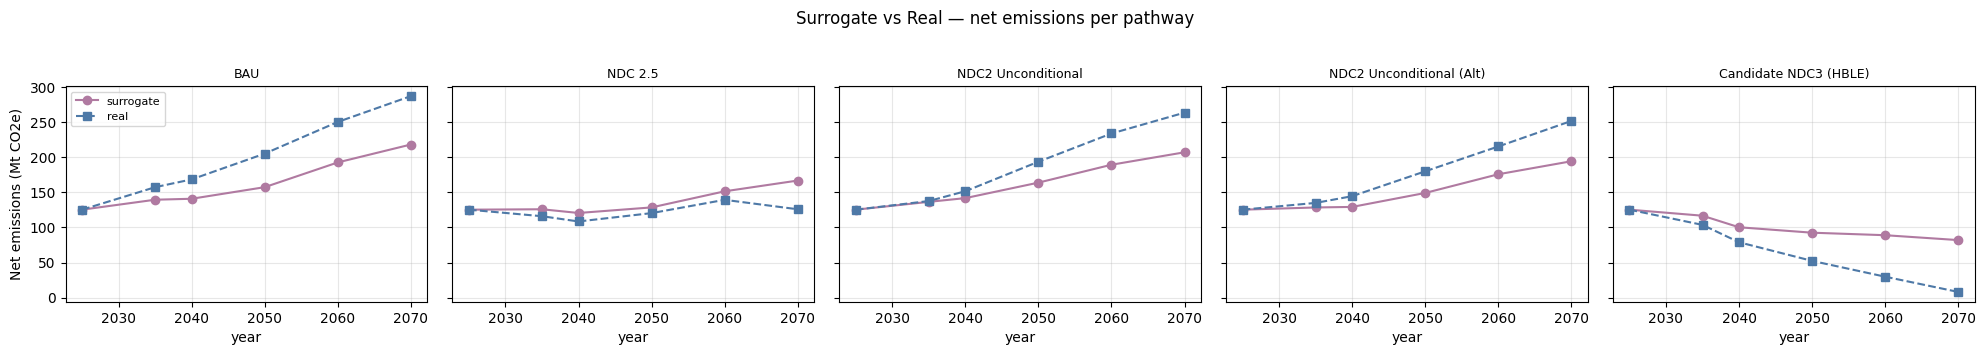

In [6]:
fig, axes = plt.subplots(1, len(PATHWAYS), figsize=(4*len(PATHWAYS), 3.4), sharey=True)
for ax, (name, pid, col) in zip(axes, PATHWAYS):
    surro, real = series[name]
    ax.plot(YEARS, [net(surro, y) for y in YEARS], 'o-', label='surrogate', color='#B07AA1')
    ax.plot(YEARS, [net(real, y) for y in YEARS], 's--', label='real', color='#4E79A7')
    ax.set_title(name, fontsize=9); ax.grid(alpha=.3)
    ax.set_xlabel('year')
axes[0].set_ylabel('Net emissions (Mt CO2e)'); axes[0].legend(fontsize=8)
plt.suptitle('Surrogate vs Real — net emissions per pathway', y=1.03)
plt.tight_layout(); plt.show()


## 6. Takeaways

- **2025 matches everywhere** — near the base year the pathways haven't diverged, so the
  surrogate is trivially correct.
- **The surrogate cannot reproduce the aggressive HBLE deep-cut**: real HBLE 2070 is ~8 Mt,
  the surrogate stays ~80 Mt. It was trained on *independent* Latin-hypercube samples and
  can't extrapolate to the coordinated, all-levers-on pathway. This is exactly why the app
  serves **real** pre-run data for the 6 named pathways.
- **Even BAU is off** (~-70 Mt at 2070) — and this is with X correctly pinned to the central
  reference. The gap is the surrogate **extrapolating to the reference future (future 0)**,
  which is outside its training sample (futures 1-12). So it's a structural limitation of the
  surrogate, not a lever/X-matching error.
- The recategorization to 23 inventory categories fixed the *composition/labelling* mismatch
  (surrogate and real now share categories and reconcile at 2019); it did **not** — and was
  not expected to — improve the surrogate's accuracy on coordinated pathways.

### To refine this test
- Match exogenous (X) drivers per pathway instead of the median default.
- Improve the lever mapping (per-year ramp instead of final-year magnitude; verify the
  magnitude<->L scale against a known run).
- Add NDC 2.0 once its lever settings are available.
